# Assignment 5

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = DataLoader(testset, batch_size=128, shuffle=False)

def train_model(model, epochs=10, weight_decay=0.0, use_dropout=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    train_acc, val_acc = [], []
    train_loss, val_loss = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
        
        train_loss.append(running_loss / len(trainloader))
        train_acc.append(100. * correct / total)
        
        # Validation
        model.eval()
        v_correct, v_total, v_loss = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                v_loss += loss.item()
                _, pred = outputs.max(1)
                v_total += labels.size(0)
                v_correct += pred.eq(labels).sum().item()
        
        val_loss.append(v_loss / len(testloader))
        val_acc.append(100. * v_correct / v_total)
        print(f"Epoch {epoch+1}: Train Acc {train_acc[-1]:.1f}%  Val Acc {val_acc[-1]:.1f}%")
    
    return train_acc, train_loss, val_acc, val_loss

def plot_curves(ta, tl, va, vl, title):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(ta, label='Train Acc')
    plt.plot(va, label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(tl, label='Train Loss')
    plt.plot(vl, label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()

/home/nazmulhasan77/tf_gpu_env/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### **Part A: Creating Underfitting and Overfitting Scenarios**

=== Part A: Underfitting Model ===
Epoch 1: Train Acc 42.7%  Val Acc 49.5%
Epoch 2: Train Acc 52.7%  Val Acc 53.3%
Epoch 3: Train Acc 55.7%  Val Acc 54.3%
Epoch 4: Train Acc 57.3%  Val Acc 54.1%
Epoch 5: Train Acc 58.8%  Val Acc 53.0%


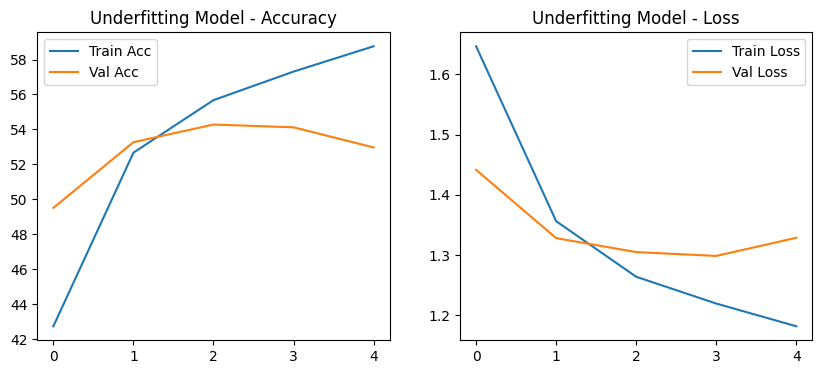

In [2]:
class UnderfitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 8, 3, padding=1)
        self.fc = nn.Linear(8*32*32, 10)
    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = x.view(x.size(0), -1)
        return self.fc(x)

print("=== Part A: Underfitting Model ===")
under_model = UnderfitCNN().to(device)
ta, tl, va, vl = train_model(under_model, epochs=5)
plot_curves(ta, tl, va, vl, "Underfitting Model")

**Discussion for Part A (Underfitting):**  
The model is very simple (only 1 conv layer). Training is short (5 epochs). Both training and validation accuracy stay low. The model cannot learn complex patterns from the images. This is underfitting.


=== Part A: Overfitting Model ===
Epoch 1: Train Acc 50.0%  Val Acc 62.4%
Epoch 2: Train Acc 68.0%  Val Acc 70.0%
Epoch 3: Train Acc 75.1%  Val Acc 74.6%
Epoch 4: Train Acc 80.4%  Val Acc 76.4%
Epoch 5: Train Acc 85.2%  Val Acc 76.9%
Epoch 6: Train Acc 89.3%  Val Acc 76.8%
Epoch 7: Train Acc 92.5%  Val Acc 76.8%
Epoch 8: Train Acc 95.1%  Val Acc 77.5%
Epoch 9: Train Acc 96.5%  Val Acc 77.9%
Epoch 10: Train Acc 97.1%  Val Acc 76.3%
Epoch 11: Train Acc 97.3%  Val Acc 76.7%
Epoch 12: Train Acc 97.6%  Val Acc 77.4%
Epoch 13: Train Acc 98.3%  Val Acc 76.7%
Epoch 14: Train Acc 98.2%  Val Acc 75.3%
Epoch 15: Train Acc 98.1%  Val Acc 76.7%
Epoch 16: Train Acc 98.2%  Val Acc 76.3%
Epoch 17: Train Acc 98.5%  Val Acc 77.0%
Epoch 18: Train Acc 98.6%  Val Acc 77.0%
Epoch 19: Train Acc 98.4%  Val Acc 76.7%
Epoch 20: Train Acc 98.7%  Val Acc 76.6%


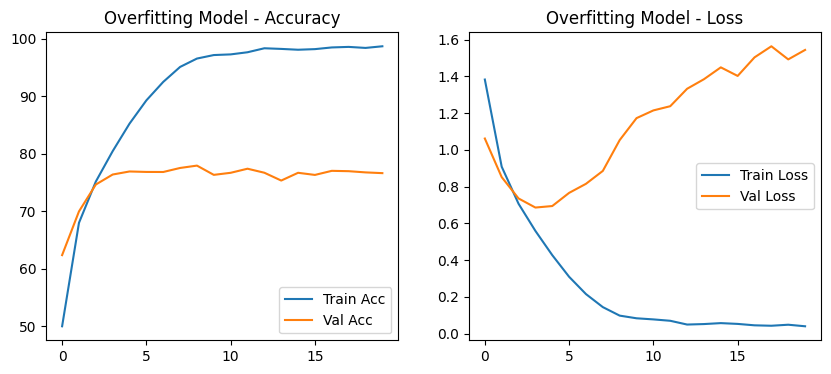

In [3]:
class OverfitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(256*4*4, 512)
        self.fc2 = nn.Linear(512, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

print("\n=== Part A: Overfitting Model ===")
over_model = OverfitCNN().to(device)
ta, tl, va, vl = train_model(over_model, epochs=20)
plot_curves(ta, tl, va, vl, "Overfitting Model")


**Discussion for Part A (Overfitting):**  
The model has many layers and parameters. After many epochs, training accuracy becomes very high but validation accuracy stops improving or becomes much lower. The model memorizes the training data instead of learning general features. This is overfitting.


### **Part B: Effect of Regularization**


=== Part B: Overfit Model with L2 Regularization ===
Epoch 1: Train Acc 49.7%  Val Acc 57.9%
Epoch 2: Train Acc 66.0%  Val Acc 69.2%
Epoch 3: Train Acc 72.4%  Val Acc 72.5%
Epoch 4: Train Acc 76.1%  Val Acc 74.4%
Epoch 5: Train Acc 78.7%  Val Acc 75.4%
Epoch 6: Train Acc 81.0%  Val Acc 76.4%
Epoch 7: Train Acc 82.7%  Val Acc 76.0%
Epoch 8: Train Acc 83.9%  Val Acc 77.3%
Epoch 9: Train Acc 85.9%  Val Acc 77.2%
Epoch 10: Train Acc 86.9%  Val Acc 78.5%
Epoch 11: Train Acc 88.6%  Val Acc 78.1%
Epoch 12: Train Acc 89.6%  Val Acc 76.5%
Epoch 13: Train Acc 90.1%  Val Acc 77.7%
Epoch 14: Train Acc 91.3%  Val Acc 78.1%
Epoch 15: Train Acc 91.9%  Val Acc 77.3%
Epoch 16: Train Acc 92.6%  Val Acc 78.2%
Epoch 17: Train Acc 92.7%  Val Acc 77.8%
Epoch 18: Train Acc 93.4%  Val Acc 78.0%
Epoch 19: Train Acc 93.7%  Val Acc 77.5%
Epoch 20: Train Acc 94.0%  Val Acc 77.0%


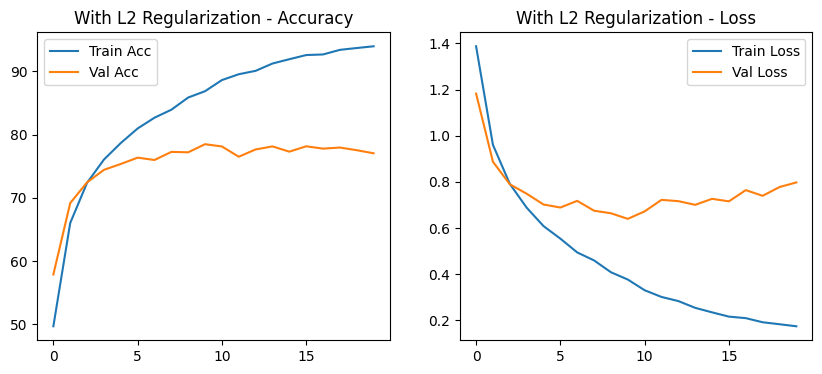

In [4]:
print("\n=== Part B: Overfit Model with L2 Regularization ===")
reg_model = OverfitCNN().to(device)
ta, tl, va, vl = train_model(reg_model, epochs=20, weight_decay=0.001)
plot_curves(ta, tl, va, vl, "With L2 Regularization")

**Discussion for Part B:**  
L2 regularization (weight_decay) adds penalty on large weights. The gap between training and validation accuracy becomes smaller. Validation accuracy improves compared to the plain overfitting model. Regularization helps the model generalize better and reduces overfitting.

### **Part C: Effect of Dropout**


=== Part C: Overfit Model with Dropout ===
Epoch 1: Train Acc 47.6%  Val Acc 61.0%
Epoch 2: Train Acc 64.6%  Val Acc 68.8%
Epoch 3: Train Acc 71.9%  Val Acc 73.1%
Epoch 4: Train Acc 76.2%  Val Acc 74.9%
Epoch 5: Train Acc 79.5%  Val Acc 77.5%
Epoch 6: Train Acc 82.5%  Val Acc 78.0%
Epoch 7: Train Acc 85.2%  Val Acc 78.9%
Epoch 8: Train Acc 87.5%  Val Acc 78.6%
Epoch 9: Train Acc 89.4%  Val Acc 78.8%
Epoch 10: Train Acc 91.0%  Val Acc 78.2%
Epoch 11: Train Acc 92.6%  Val Acc 78.1%
Epoch 12: Train Acc 93.5%  Val Acc 78.6%
Epoch 13: Train Acc 94.2%  Val Acc 78.4%
Epoch 14: Train Acc 94.9%  Val Acc 78.7%
Epoch 15: Train Acc 95.1%  Val Acc 78.4%
Epoch 16: Train Acc 95.6%  Val Acc 78.3%
Epoch 17: Train Acc 96.0%  Val Acc 78.5%
Epoch 18: Train Acc 96.2%  Val Acc 78.4%
Epoch 19: Train Acc 96.5%  Val Acc 78.8%
Epoch 20: Train Acc 96.5%  Val Acc 78.5%


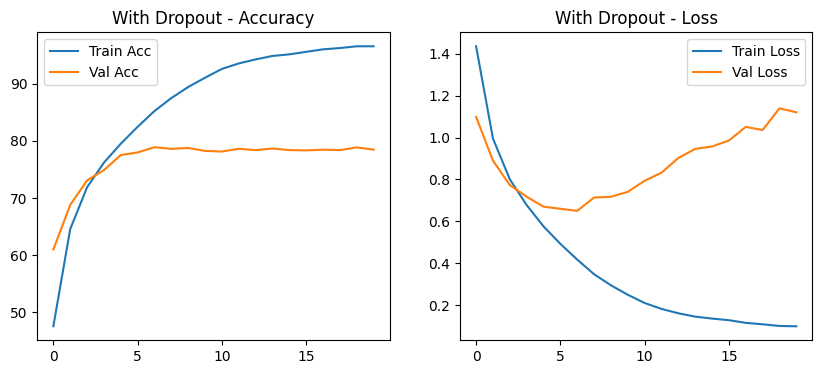

In [5]:
class DropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256*4*4, 512)
        self.fc2 = nn.Linear(512, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

print("\n=== Part C: Overfit Model with Dropout ===")
drop_model = DropoutCNN().to(device)
ta, tl, va, vl = train_model(drop_model, epochs=20)
plot_curves(ta, tl, va, vl, "With Dropout")

**Discussion for Part C:**  
Dropout randomly turns off some neurons during training. This forces the model to learn more robust features. Overfitting is reduced. Validation accuracy is better and more stable than the original overfitting model. The model becomes stronger against noise.

### **Part D: Combined Effect of Regularization and Dropout**


=== Part D: Combined L2 + Dropout ===
Epoch 1: Train Acc 46.3%  Val Acc 58.8%
Epoch 2: Train Acc 62.2%  Val Acc 66.8%
Epoch 3: Train Acc 68.8%  Val Acc 70.7%
Epoch 4: Train Acc 72.6%  Val Acc 72.5%
Epoch 5: Train Acc 75.3%  Val Acc 73.6%
Epoch 6: Train Acc 77.2%  Val Acc 76.2%
Epoch 7: Train Acc 79.0%  Val Acc 77.3%
Epoch 8: Train Acc 80.2%  Val Acc 77.6%
Epoch 9: Train Acc 81.3%  Val Acc 77.0%
Epoch 10: Train Acc 82.4%  Val Acc 78.7%
Epoch 11: Train Acc 83.3%  Val Acc 79.1%
Epoch 12: Train Acc 84.3%  Val Acc 78.0%
Epoch 13: Train Acc 85.0%  Val Acc 78.1%
Epoch 14: Train Acc 85.9%  Val Acc 79.3%
Epoch 15: Train Acc 86.6%  Val Acc 79.2%
Epoch 16: Train Acc 86.9%  Val Acc 80.1%
Epoch 17: Train Acc 87.6%  Val Acc 80.4%
Epoch 18: Train Acc 88.2%  Val Acc 77.5%
Epoch 19: Train Acc 88.6%  Val Acc 78.7%
Epoch 20: Train Acc 88.7%  Val Acc 79.5%


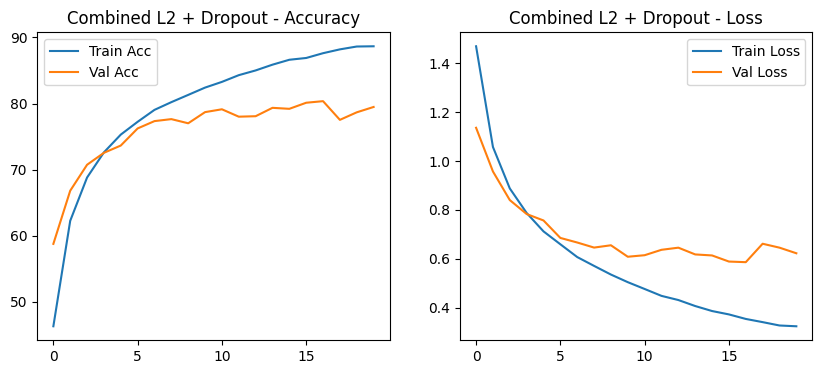

In [6]:
class CombinedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256*4*4, 512)
        self.fc2 = nn.Linear(512, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

print("\n=== Part D: Combined L2 + Dropout ===")
comb_model = CombinedCNN().to(device)
ta, tl, va, vl = train_model(comb_model, epochs=20, weight_decay=0.001)
plot_curves(ta, tl, va, vl, "Combined L2 + Dropout")

**Discussion for Part D:**  
Combining L2 regularization and Dropout gives the best result. Training and validation curves are closest. Validation accuracy is highest among all cases. The model generalizes well without memorizing the training data.

**Overall Conclusion:**  
Underfitting happens when the model is too weak. Overfitting happens when the model is too strong without control. Regularization and Dropout both reduce overfitting. Using them together works best. This helps the CNN learn useful features instead of noise.